5th Percentile: 14.75
95th Percentile: 98.1
Q1: 43.75
Q3: 82.75
IQR: 39.0
Lower Bound: -14.75
Upper Bound: 141.25

Z-Score Outliers:
    Study_Hours  Exam_Score  Z_Score
15            5          10 -2.00059

Covariance: 138.92105263157893
Pearson Correlation: 0.589484443995757
Spearman Correlation: 0.6109858764987233


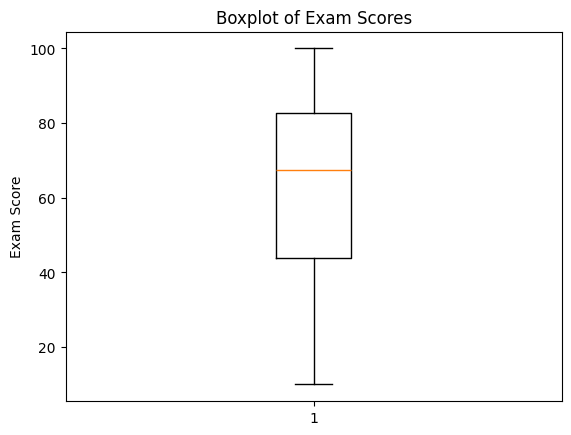

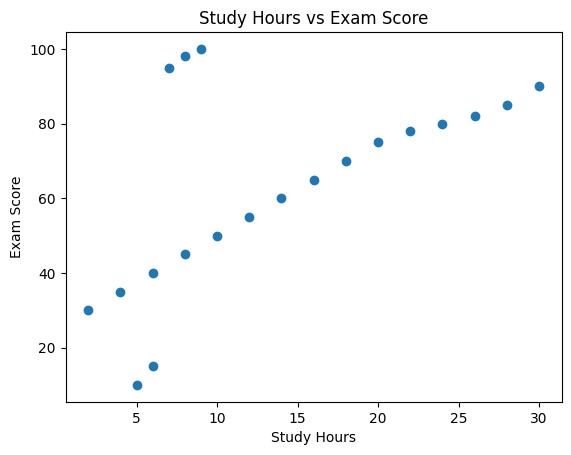

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore, spearmanr, pearsonr

# -----------------------------
# Dataset
# -----------------------------
data = {
    "Study_Hours": [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,5,6,7,8,9],
    "Exam_Score": [30,35,40,45,50,55,60,65,70,75,78,80,82,85,90,10,15,95,98,100]
}

df = pd.DataFrame(data)

# -----------------------------
# 1. Percentile Method
# -----------------------------
p5 = np.percentile(df["Exam_Score"], 5)
p95 = np.percentile(df["Exam_Score"], 95)

print("5th Percentile:", p5)
print("95th Percentile:", p95)

# -----------------------------
# 2. Quartiles & IQR
# -----------------------------
Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# -----------------------------
# 3. Z-Score Method
# -----------------------------
df["Z_Score"] = zscore(df["Exam_Score"])
outliers_z = df[np.abs(df["Z_Score"]) > 2]

print("\nZ-Score Outliers:")
print(outliers_z)

# -----------------------------
# 4. Covariance
# -----------------------------
covariance = np.cov(df["Study_Hours"], df["Exam_Score"])[0][1]
print("\nCovariance:", covariance)

# -----------------------------
# 5. Pearson Correlation
# -----------------------------
pearson_corr, _ = pearsonr(df["Study_Hours"], df["Exam_Score"])
print("Pearson Correlation:", pearson_corr)

# -----------------------------
# 6. Spearman Correlation
# -----------------------------
spearman_corr, _ = spearmanr(df["Study_Hours"], df["Exam_Score"])
print("Spearman Correlation:", spearman_corr)

# -----------------------------
# 7. Boxplot (Outliers)
# -----------------------------
plt.figure()
plt.boxplot(df["Exam_Score"])
plt.title("Boxplot of Exam Scores")
plt.ylabel("Exam Score")
plt.show()

# -----------------------------
# 8. Scatter Plot
# -----------------------------
plt.figure()
plt.scatter(df["Study_Hours"], df["Exam_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()
